
Output directory created: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT

Running YOLOv8 Detection Evaluation...
YOLOv8 model loaded successfully
YOLOv8 model loaded successfully
Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
✓ Annotations directory found: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\ANNOTATIONS
Training AMFF-CNN...



Epoch 1/50


45/45 [==============================] - 183s 4s/step - loss: 1.7157 - accuracy: 0.2201 - val_loss: 1.7323 - val_accuracy: 0.1591
Epoch 2/50
45/45 [==============================] - 163s 4s/step - loss: 1.5742 - accuracy: 0.3368 - val_loss: 1.0950 - val_accuracy: 0.5540
Epoch 3/50
45/45 [==============================] - 160s 4s/step - loss: 1.0565 - accuracy: 0.5424 - val_loss: 0.8275 - val_accuracy: 0.6193
Epoch 4/50
45/45 [==============================] - 155s 3s/step - loss: 0.7376 - accuracy: 0.7271 - val_loss: 0.5648 - val_accuracy: 

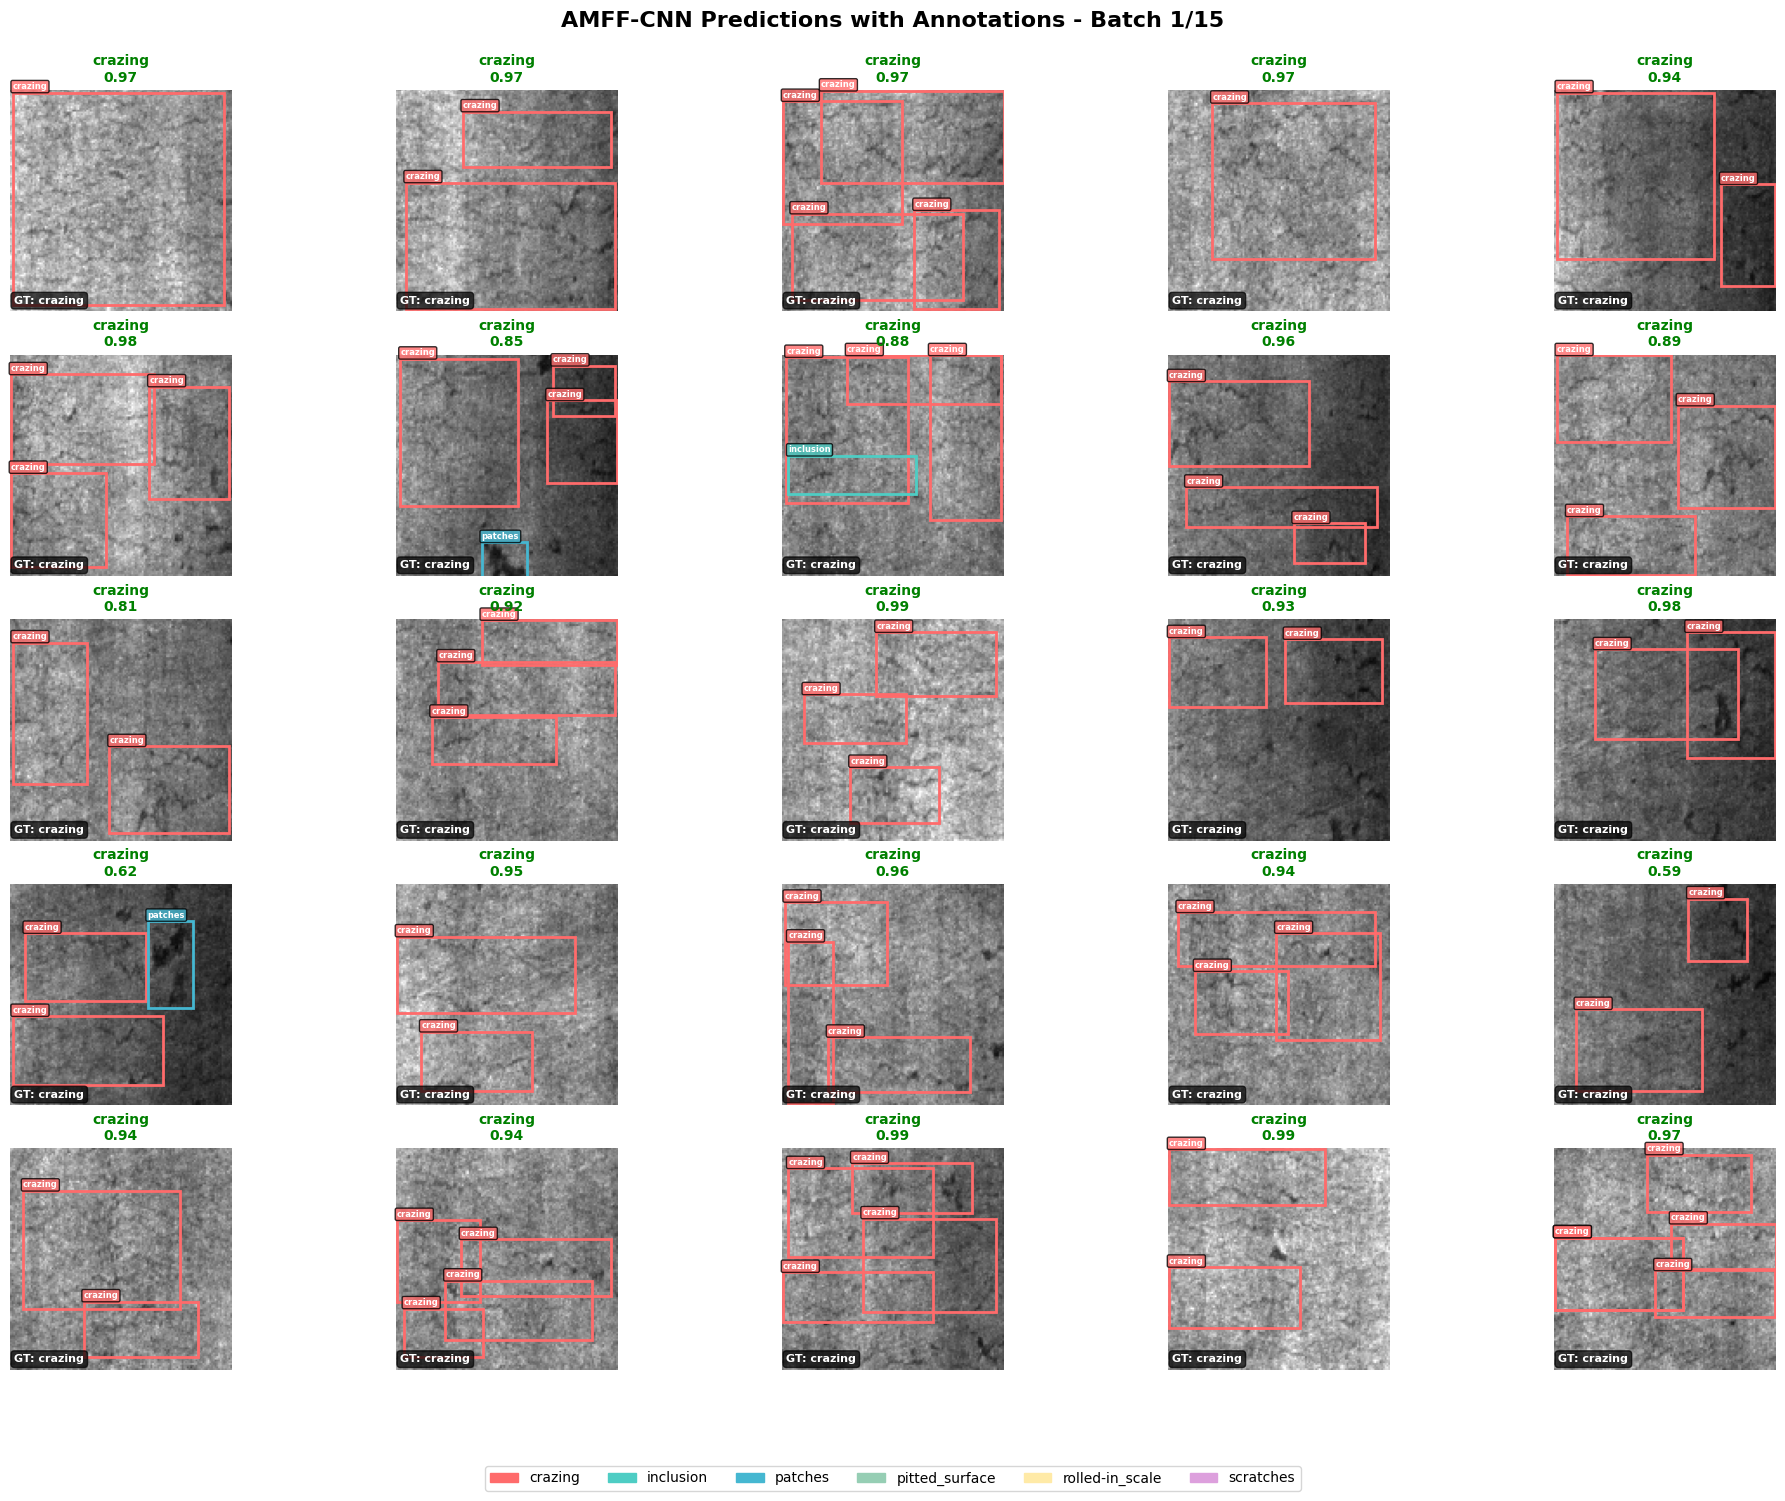

Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_2.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_3.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_4.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_5.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_6.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_7.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_8.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_9.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\AMFF-CNN_batch_10.png
Saved: C:\Users\an

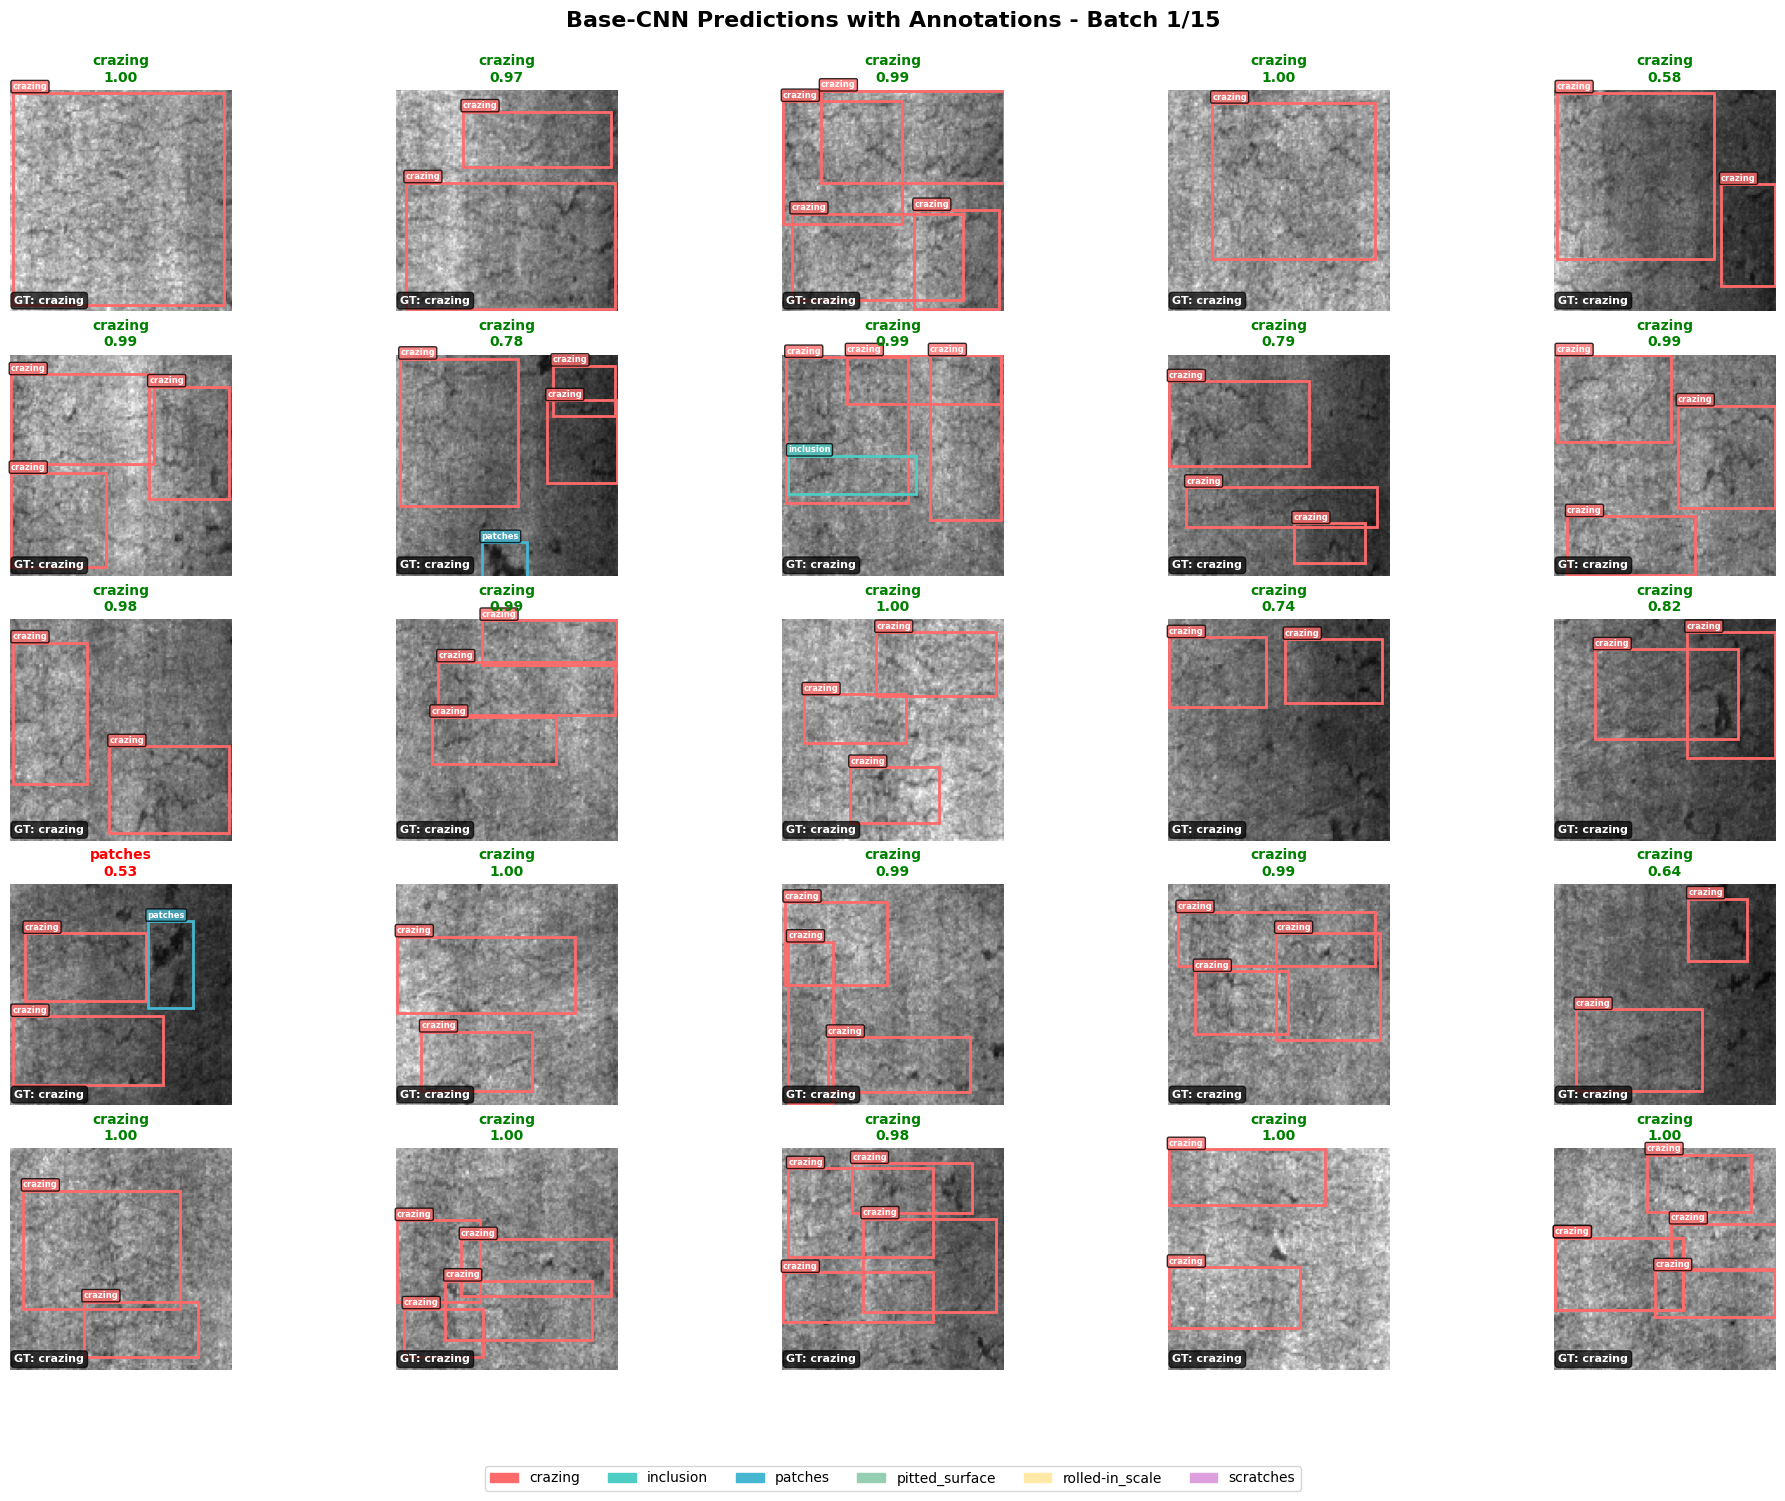

Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_2.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_3.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_4.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_5.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_6.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_7.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_8.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_9.png
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_batch_10.png
Saved: C:\Users\an

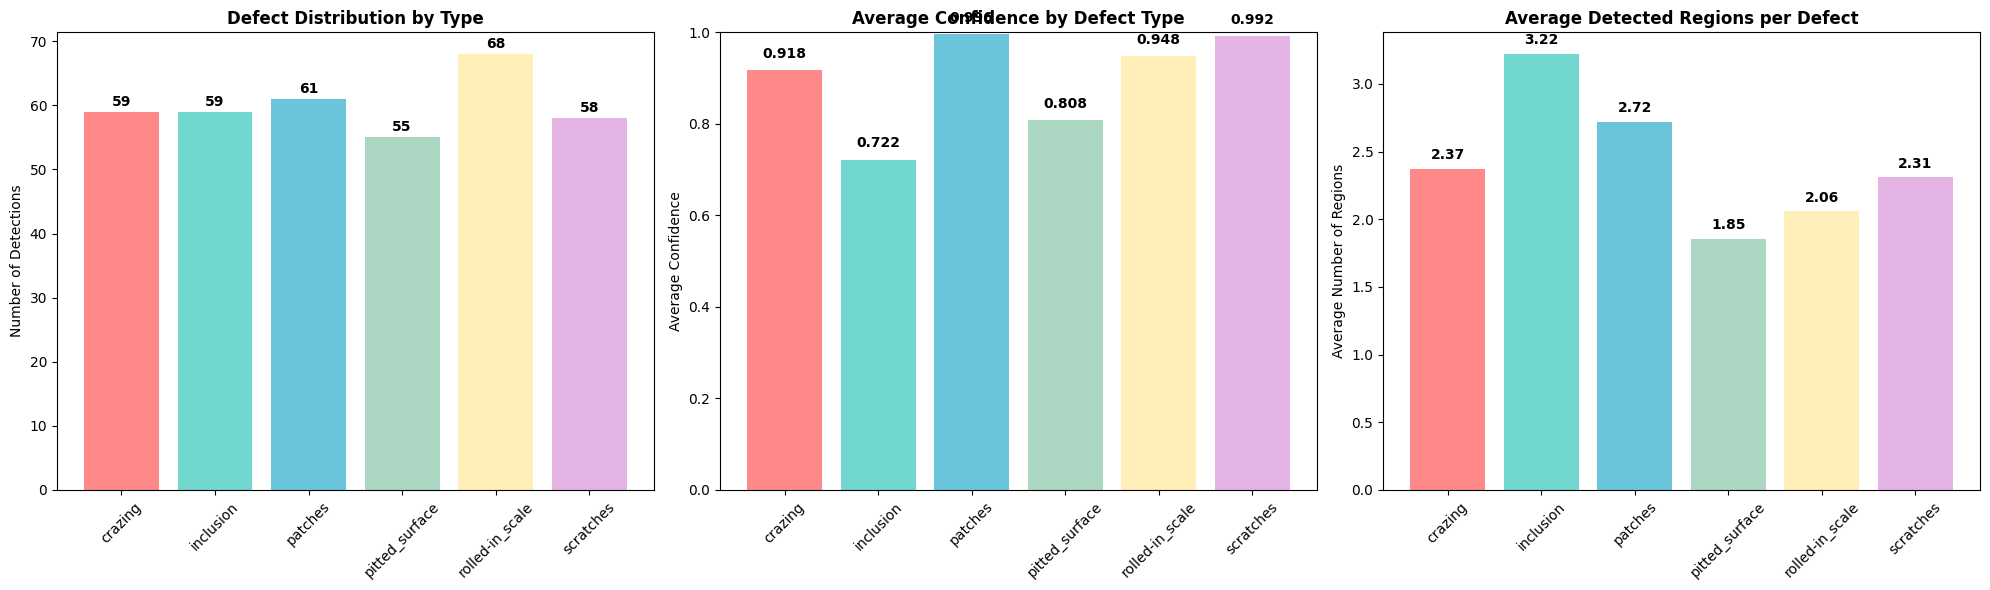

Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\Base-CNN_area_analysis.png


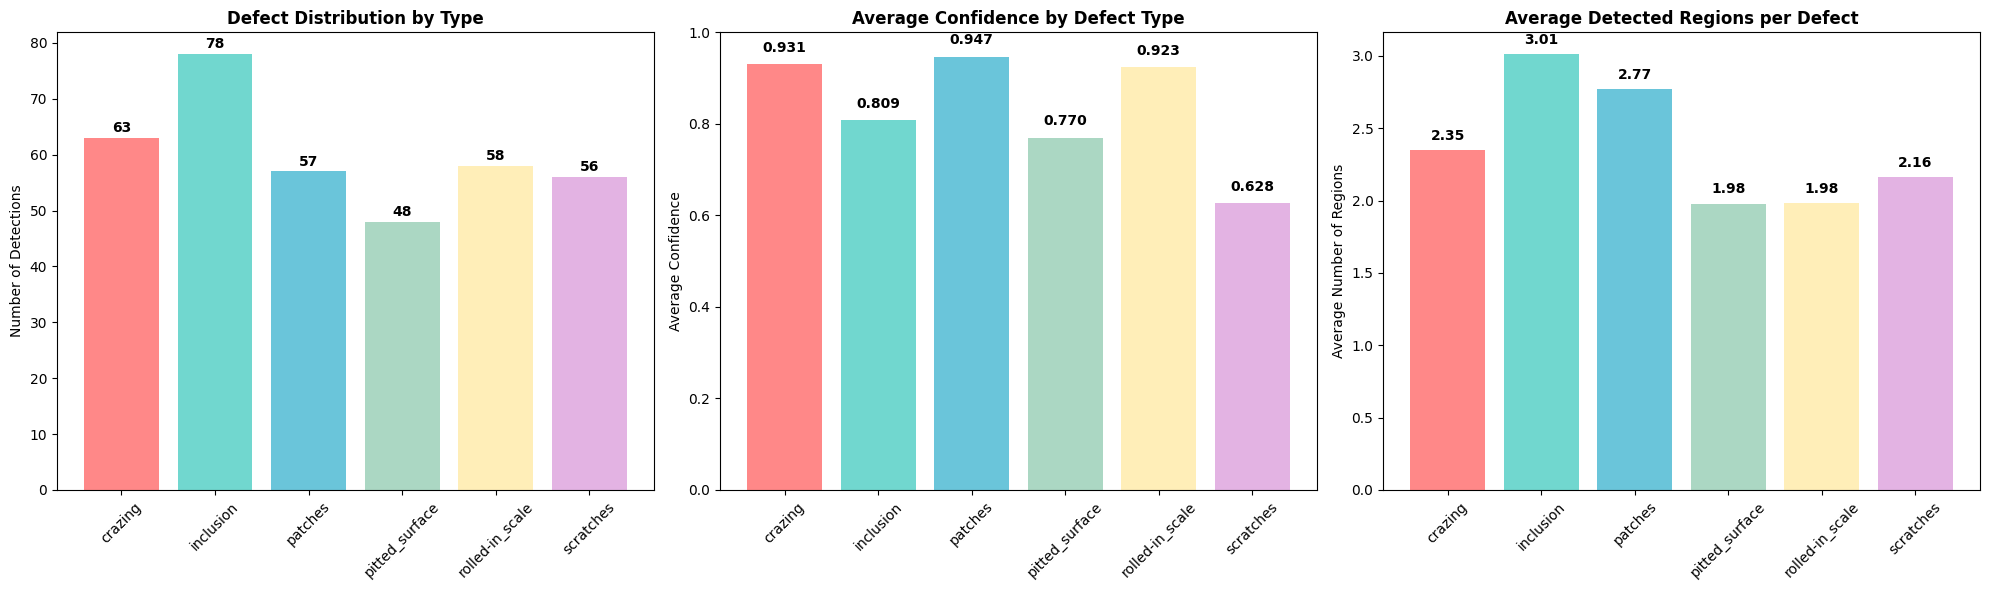


=== Performance Comparison ===
AMFF-CNN Accuracy: 0.9659
Base CNN Accuracy: 0.8750
Improvement: 0.0909

AMFF-CNN - Total regions detected: 872
AMFF-CNN - Average regions per image: 2.42
Base-CNN - Total regions detected: 872
Base-CNN - Average regions per image: 2.42
Saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\model_comparison.png


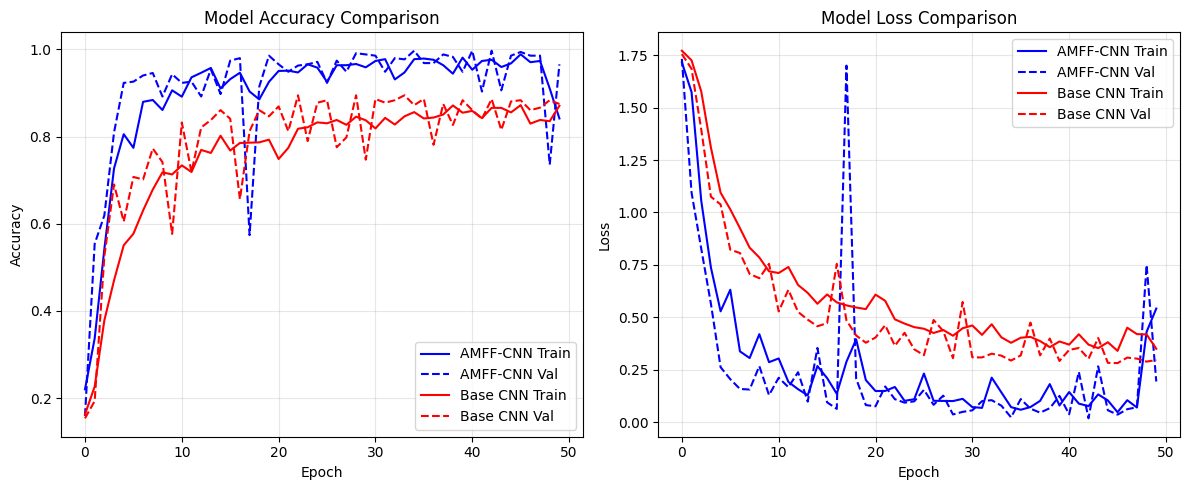

✓ AMFF-CNN model saved at: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\amff_cnn_final.h5
✓ Base-CNN model saved at: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT\base_cnn_final.h5


In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
import math
import cv2
import json
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw, ImageFont
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
except ImportError:
    print("Warning: ultralytics not available. Install with: pip install ultralytics")
    YOLO_AVAILABLE = False

img_size = 128
batch_size = 32
epochs = 50
class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
num_classes = len(class_names)
input_shape = (img_size, img_size, 3)
images_dir = r"C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\IMAGES"
annotations_dir = r"C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\NEU-DET\ANNOTATIONS"  

output_dir = r"C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\YOLO_OUTPUT"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory created: {output_dir}")

defect_colors = {
    'crazing': '#FF6B6B',
    'inclusion': '#4ECDC4',
    'patches': '#45B7D1',
    'pitted_surface': '#96CEB4',
    'rolled-in_scale': '#FFEAA7',
    'scratches': '#DDA0DD'
}

def load_annotations(annotations_dir, img_filename, original_size, target_size):
    """
    Load annotations from JSON or XML files
    Supports multiple formats:
    - JSON: {"boxes": [[x, y, w, h], ...], "labels": [...]}
    - XML: Pascal VOC format
    - TXT: YOLO format (class x_center y_center width height)
    """
    base_name = os.path.splitext(img_filename)[0]
    regions = []
    
    # Try JSON format
    json_path = os.path.join(annotations_dir, base_name + '.json')
    if os.path.exists(json_path):
        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
            
            boxes = data.get('boxes', [])
            labels = data.get('labels', [])
            
            scale_x = target_size[1] / original_size[1]
            scale_y = target_size[0] / original_size[0]
            
            for i, box in enumerate(boxes):
                x, y, w, h = box
                scaled_box = [
                    int(x * scale_x),
                    int(y * scale_y),
                    int(w * scale_x),
                    int(h * scale_y)
                ]
                regions.append({
                    'bbox': scaled_box,
                    'label': labels[i] if i < len(labels) else 'unknown',
                    'area': scaled_box[2] * scaled_box[3],
                    'confidence': 1.0
                })
            return regions
        except Exception as e:
            print(f"Error loading JSON annotation for {img_filename}: {e}")
    
    # Try XML format (Pascal VOC)
    xml_path = os.path.join(annotations_dir, base_name + '.xml')
    if os.path.exists(xml_path):
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            size = root.find('size')
            orig_w = int(size.find('width').text)
            orig_h = int(size.find('height').text)
            
            scale_x = target_size[1] / orig_w
            scale_y = target_size[0] / orig_h
            
            for obj in root.findall('object'):
                label = obj.find('name').text
                bbox = obj.find('bndbox')
                xmin = int(float(bbox.find('xmin').text) * scale_x)
                ymin = int(float(bbox.find('ymin').text) * scale_y)
                xmax = int(float(bbox.find('xmax').text) * scale_x)
                ymax = int(float(bbox.find('ymax').text) * scale_y)
                
                w = xmax - xmin
                h = ymax - ymin
                
                regions.append({
                    'bbox': [xmin, ymin, w, h],
                    'label': label,
                    'area': w * h,
                    'confidence': 1.0
                })
            return regions
        except Exception as e:
            print(f"Error loading XML annotation for {img_filename}: {e}")
    
    # Try TXT format (YOLO)
    txt_path = os.path.join(annotations_dir, base_name + '.txt')
    if os.path.exists(txt_path):
        try:
            with open(txt_path, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1]) * target_size[1]
                    y_center = float(parts[2]) * target_size[0]
                    w = float(parts[3]) * target_size[1]
                    h = float(parts[4]) * target_size[0]
                    
                    x = int(x_center - w/2)
                    y = int(y_center - h/2)
                    w = int(w)
                    h = int(h)
                    
                    label = class_names[class_id] if class_id < len(class_names) else 'unknown'
                    
                    regions.append({
                        'bbox': [x, y, w, h],
                        'label': label,
                        'area': w * h,
                        'confidence': 1.0
                    })
            return regions
        except Exception as e:
            print(f"Error loading TXT annotation for {img_filename}: {e}")
    
    return None

class YOLOv8PreDetector:
    def __init__(self, model_path=None):
        self.model = None
        if YOLO_AVAILABLE:
            try:
                if model_path and os.path.exists(model_path):
                    self.model = YOLO(model_path)
                else:
                    self.model = YOLO('yolov8n.pt')
                print("YOLOv8 model loaded successfully")
            except Exception as e:
                print(f"Error loading YOLOv8: {e}")

    def get_yolo_predictions(self, image_dir, annotations_dir, conf=0.3):
        predictions = []

        for img_name in os.listdir(image_dir):
            if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(image_dir, img_name)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            results = self.model(img_rgb, conf=conf)
            regions = []

            for result in results:
                if result.boxes is None:
                    continue
                for box in result.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    cls = int(box.cls[0])
                    conf_score = float(box.conf[0])

                    label = class_names[cls] if cls < len(class_names) else "unknown"

                    regions.append({
                        "bbox": [int(x1), int(y1), int(x2-x1), int(y2-y1)],
                        "label": label,
                        "confidence": conf_score
                    })

            # Load ground truth boxes
            gt_regions = load_annotations(
                annotations_dir,
                img_name,
                img.shape[:2],
                (img.shape[0], img.shape[1])
            ) or []

            predictions.append({
                "image_id": img_name,
                "regions": regions,
                "gt_regions": gt_regions
            })

        return predictions

print("\nRunning YOLOv8 Detection Evaluation...")

yolo_detector = YOLOv8PreDetector()
yolo_predictions = yolo_detector.get_yolo_predictions(images_dir, annotations_dir, conf=0.3)






class YOLOv8PreDetector:
    def __init__(self, model_path=None):
        self.model = None
        if YOLO_AVAILABLE:
            try:
                if model_path and os.path.exists(model_path):
                    self.model = YOLO(model_path)
                else:
                    self.model = YOLO('yolov8n.pt')
                print("YOLOv8 model loaded successfully")
            except Exception as e:
                print(f"Error loading YOLOv8: {e}")

    def get_yolo_predictions(self, image_dir, annotations_dir, conf=0.3):
        predictions = []

        for img_name in os.listdir(image_dir):
            if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(image_dir, img_name)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            results = self.model(img_rgb, conf=conf)
            regions = []

            for result in results:
                if result.boxes is None:
                    continue
                for box in result.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    cls = int(box.cls[0])
                    conf_score = float(box.conf[0])

                    label = class_names[cls] if cls < len(class_names) else "unknown"

                    regions.append({
                        "bbox": [int(x1), int(y1), int(x2-x1), int(y2-y1)],
                        "label": label,
                        "confidence": conf_score
                    })

            # Load ground truth boxes
            gt_regions = load_annotations(
                annotations_dir,
                img_name,
                img.shape[:2],
                (img.shape[0], img.shape[1])
            ) or []

            predictions.append({
                "image_id": img_name,
                "regions": regions,
                "gt_regions": gt_regions
            })

        return predictions

    def detect_regions(self, image, confidence=0.3):
        if self.model is None:
            h, w = image.shape[:2]
            return [{'bbox': [0, 0, w, h], 'confidence': 1.0, 'class': 'unknown'}]
        
        try:
            results = self.model(image, conf=confidence)
            regions = []
            for result in results:
                boxes = result.boxes
                if boxes is not None:
                    for box in boxes:
                        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                        conf = box.conf[0].cpu().numpy()
                        cls = int(box.cls[0].cpu().numpy()) if len(box.cls) > 0 else 0
                        regions.append({
                            'bbox': [int(x1), int(y1), int(x2-x1), int(y2-y1)],
                            'confidence': float(conf),
                            'class': cls
                        })
            if not regions:
                h, w = image.shape[:2]
                regions = [{'bbox': [0, 0, w, h], 'confidence': 1.0, 'class': 'unknown'}]
            return regions
        except Exception as e:
            print(f"Error in YOLOv8 detection: {e}")
            h, w = image.shape[:2]
            return [{'bbox': [0, 0, w, h], 'confidence': 1.0, 'class': 'unknown'}]

yolo_detector = YOLOv8PreDetector()

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    images_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = datagen.flow_from_directory(
    images_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

steps_per_epoch = train_generator.samples // batch_size
validation_steps = val_generator.samples // batch_size

def seam_module(input_tensor, filters):
    d1 = layers.Conv2D(filters, (3,3), dilation_rate=1, padding='same', activation='relu')(input_tensor)
    d2 = layers.Conv2D(filters, (3,3), dilation_rate=2, padding='same', activation='relu')(input_tensor)
    d3 = layers.Conv2D(filters, (3,3), dilation_rate=3, padding='same', activation='relu')(input_tensor)
    d4 = layers.Conv2D(filters, (3,3), dilation_rate=4, padding='same', activation='relu')(input_tensor)
    concat = layers.Concatenate()([d1, d2, d3, d4])
    conv_fused = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(concat)
    gap = layers.GlobalAveragePooling2D()(conv_fused)
    dense_1 = layers.Dense(filters // 8, activation='relu')(gap)
    dense_2 = layers.Dense(filters, activation='sigmoid')(dense_1)
    channel_attention = layers.Multiply()([conv_fused, layers.Reshape((1, 1, filters))(dense_2)])
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_attention)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_attention)
    concat_spatial = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention = layers.Conv2D(1, (7,7), padding='same', activation='sigmoid')(concat_spatial)
    spatial_out = layers.Multiply()([channel_attention, spatial_attention])
    return spatial_out

def ceam_module(current, previous, filters):
    target_shape = tf.keras.backend.int_shape(current)[1:3]
    prev_resized = layers.Lambda(lambda x: tf.image.resize(x, target_shape))(previous)
    prev_resized = layers.Conv2D(filters, (1,1), padding='same')(prev_resized)
    guided = layers.Conv2D(filters, (3,3), padding='same', activation='sigmoid')(current)
    modulated = layers.Multiply()([prev_resized, guided])
    return modulated

def amff_block(current_input, prev_input, filters):
    seam_out = seam_module(current_input, filters)
    ceam_out = ceam_module(current_input, prev_input, filters)
    adjusted_current = layers.Conv2D(filters, (1, 1), padding='same')(current_input)
    combined = layers.Add()([seam_out, ceam_out, adjusted_current])
    return combined

def build_amff_cnn(input_shape=(128, 128, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)
    x1 = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x1 = layers.MaxPooling2D()(x1)
    x2 = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x1)
    x2 = layers.MaxPooling2D()(x2)
    x3 = amff_block(x2, x1, 64)
    x3 = layers.MaxPooling2D()(x3)
    x4 = amff_block(x3, x2, 128)
    x4 = layers.GlobalAveragePooling2D()(x4)
    x4 = layers.Dense(128, activation='relu')(x4)
    x4 = layers.Dropout(0.5)(x4)
    outputs = layers.Dense(num_classes, activation='softmax')(x4)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_base_cnn(input_shape=(128, 128, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def get_enhanced_predictions_with_annotations(model, generator, class_names, annotations_dir=None, use_yolo=False, yolo_detector=None):
    generator.reset()
    predictions = []
    total = min(generator.samples, 500)
    filenames = generator.filenames
    
    for i in range(min(len(generator), 20)):
        images, labels = generator[i]
        for j in range(len(images)):
            if len(predictions) >= total:
                break
            img = images[j]
            img_idx = i * generator.batch_size + j
            img_filename = os.path.basename(filenames[img_idx]) if img_idx < len(filenames) else f"img_{img_idx}.jpg"
            
            true_label = class_names[np.argmax(labels[j])]
            pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
            pred_label = class_names[np.argmax(pred[0])]
            confidence = np.max(pred[0])
            
            # Try to load annotations first
            regions = None
            if annotations_dir and os.path.exists(annotations_dir):
                regions = load_annotations(annotations_dir, img_filename, 
                                         (img.shape[0], img.shape[1]), 
                                         (img_size, img_size))
            
            # Fallback to YOLO if no annotations found
            if regions is None and use_yolo and yolo_detector:
                img_uint8 = (img * 255).astype(np.uint8)
                yolo_regions = yolo_detector.detect_regions(img_uint8)
                regions = [{
                    'bbox': r['bbox'],
                    'label': pred_label,
                    'confidence': r['confidence']
                } for r in yolo_regions]
            
            # Final fallback: full image
            if regions is None or len(regions) == 0:
                h, w = img.shape[:2]
                regions = [{'bbox': [0, 0, w, h], 'label': pred_label, 'confidence': confidence}]
            
            predictions.append({
                'image': img,
                'filename': img_filename,
                'true_label': true_label,
                'pred_label': pred_label,
                'confidence': confidence,
                'regions': regions
            })
        if len(predictions) >= total:
            break
    return predictions

def create_paper_style_visualization(predictions, model_name, batch_size=25, display_limit=10):
    total_images = len(predictions)
    batches = math.ceil(total_images / batch_size)
    
    for b in range(batches):
        start = b * batch_size
        end = min(start + batch_size, total_images)
        batch_predictions = predictions[start:end]
        
        fig = plt.figure(figsize=(20, 16))
        fig.patch.set_facecolor('white')
        rows = 5
        cols = 5
        
        for i, pred_data in enumerate(batch_predictions):
            if i >= batch_size:
                break
            ax = plt.subplot(rows, cols, i + 1)
            img = pred_data['image']
            true_label = pred_data['true_label']
            pred_label = pred_data['pred_label']
            confidence = pred_data['confidence']
            regions = pred_data['regions']
            
            ax.imshow(img)
            
            # Draw bounding boxes from annotations
            if regions:
                for region in regions[:5]:  # Limit to 5 regions per image
                    bbox = region['bbox']
                    x, y, w, h = bbox
                    region_label = region.get('label', pred_label)
                    
                    color = defect_colors.get(region_label, '#FF0000')
                    rect = Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    
                    # Add label text on bounding box
                    label_text = region_label
                    ax.text(x, y-2, label_text, fontsize=6, color='white', 
                           fontweight='bold', bbox=dict(boxstyle="round,pad=0.2", 
                           facecolor=color, alpha=0.8))
            
            is_correct = (true_label == pred_label)
            title_color = 'green' if is_correct else 'red'
            title = f"{pred_label}\n{confidence:.2f}"
            ax.set_title(title, fontsize=10, color=title_color, fontweight='bold')
            ax.text(2, img.shape[0]-5, f"GT: {true_label}", 
                   fontsize=8, color='white', fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
        
        plt.suptitle(f'{model_name} Predictions with Annotations - Batch {b+1}/{batches}', 
                    fontsize=16, fontweight='bold', y=0.95)
        legend_elements = [patches.Patch(color=color, label=defect) 
                          for defect, color in defect_colors.items()]
        plt.figlegend(handles=legend_elements, loc='lower center', 
                     ncol=len(class_names), fontsize=10, 
                     bbox_to_anchor=(0.5, 0.02))
        plt.tight_layout()
        plt.subplots_adjust(top=0.90, bottom=0.1)
        
        save_path = os.path.join(output_dir, f'{model_name}_batch_{b+1}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
        
        if b == 0 and display_limit > 0:
            plt.show()
        else:
            plt.close()

def create_area_wise_analysis(predictions, class_names, model_name):
    area_stats = {class_name: {'count': 0, 'total_confidence': 0, 'total_regions': 0} 
                  for class_name in class_names}
    
    for pred_data in predictions:
        pred_label = pred_data['pred_label']
        confidence = pred_data['confidence']
        num_regions = len(pred_data['regions'])
        
        area_stats[pred_label]['count'] += 1
        area_stats[pred_label]['total_confidence'] += confidence
        area_stats[pred_label]['total_regions'] += num_regions
    
    for class_name in area_stats:
        if area_stats[class_name]['count'] > 0:
            area_stats[class_name]['avg_confidence'] = area_stats[class_name]['total_confidence'] / area_stats[class_name]['count']
            area_stats[class_name]['avg_regions'] = area_stats[class_name]['total_regions'] / area_stats[class_name]['count']
        else:
            area_stats[class_name]['avg_confidence'] = 0
            area_stats[class_name]['avg_regions'] = 0
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    
    classes = list(area_stats.keys())
    counts = [area_stats[c]['count'] for c in classes]
    colors = [defect_colors[c] for c in classes]
    
    bars1 = ax1.bar(classes, counts, color=colors, alpha=0.8)
    ax1.set_title('Defect Distribution by Type', fontweight='bold')
    ax1.set_ylabel('Number of Detections')
    ax1.tick_params(axis='x', rotation=45)
    for bar, count in zip(bars1, counts):
        if count > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', va='bottom', fontweight='bold')
    
    avg_confidences = [area_stats[c]['avg_confidence'] for c in classes]
    bars2 = ax2.bar(classes, avg_confidences, color=colors, alpha=0.8)
    ax2.set_title('Average Confidence by Defect Type', fontweight='bold')
    ax2.set_ylabel('Average Confidence')
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis='x', rotation=45)
    for bar, conf in zip(bars2, avg_confidences):
        if conf > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{conf:.3f}', ha='center', va='bottom', fontweight='bold')
    
    avg_regions = [area_stats[c]['avg_regions'] for c in classes]
    bars3 = ax3.bar(classes, avg_regions, color=colors, alpha=0.8)
    ax3.set_title('Average Detected Regions per Defect', fontweight='bold')
    ax3.set_ylabel('Average Number of Regions')
    ax3.tick_params(axis='x', rotation=45)
    for bar, reg in zip(bars3, avg_regions):
        if reg > 0:
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{reg:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, f'{model_name}_area_analysis.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()

# Check if annotations directory exists
use_annotations = os.path.exists(annotations_dir)
if use_annotations:
    print(f"✓ Annotations directory found: {annotations_dir}")
else:
    print(f"✗ Annotations directory not found: {annotations_dir}")
    print("Will use YOLO detection as fallback")

print("Training AMFF-CNN...")
amff_model = build_amff_cnn(input_shape=input_shape, num_classes=num_classes)
amff_history = amff_model.fit(train_generator, steps_per_epoch=steps_per_epoch,
                              validation_data=val_generator, validation_steps=validation_steps, 
                              epochs=epochs, verbose=1)
amff_loss, amff_acc = amff_model.evaluate(val_generator, steps=validation_steps, verbose=0)

print("Training Base CNN...")
base_model = build_base_cnn(input_shape=input_shape, num_classes=num_classes)
base_history = base_model.fit(train_generator, steps_per_epoch=steps_per_epoch,
                              validation_data=val_generator, validation_steps=validation_steps, 
                              epochs=epochs, verbose=1)
base_loss, base_acc = base_model.evaluate(val_generator, steps=validation_steps, verbose=0)

print("Generating AMFF-CNN predictions with annotations...")
amff_predictions = get_enhanced_predictions_with_annotations(
    amff_model, val_generator, class_names, 
    annotations_dir=annotations_dir if use_annotations else None,
    use_yolo=True, yolo_detector=yolo_detector
)

print("Generating Base CNN predictions with annotations...")
base_predictions = get_enhanced_predictions_with_annotations(
    base_model, val_generator, class_names,
    annotations_dir=annotations_dir if use_annotations else None,
    use_yolo=True, yolo_detector=yolo_detector
)

print("Creating AMFF-CNN visualization (displaying first 10 images only)...")
create_paper_style_visualization(amff_predictions, "AMFF-CNN", batch_size=25, display_limit=10)

print("Creating Base CNN visualization (displaying first 10 images only)...")
create_paper_style_visualization(base_predictions, "Base-CNN", batch_size=25, display_limit=10)

print("Creating area-wise defect analysis...")
create_area_wise_analysis(amff_predictions, class_names, "AMFF-CNN")
create_area_wise_analysis(base_predictions, class_names, "Base-CNN")

print(f"\n=== Performance Comparison ===")
print(f"AMFF-CNN Accuracy: {amff_acc:.4f}")
print(f"Base CNN Accuracy: {base_acc:.4f}")
print(f"Improvement: {amff_acc - base_acc:.4f}")

# Additional statistics
total_amff_regions = sum([len(p['regions']) for p in amff_predictions])
total_base_regions = sum([len(p['regions']) for p in base_predictions])
print(f"\nAMFF-CNN - Total regions detected: {total_amff_regions}")
print(f"AMFF-CNN - Average regions per image: {total_amff_regions/len(amff_predictions):.2f}")
print(f"Base-CNN - Total regions detected: {total_base_regions}")
print(f"Base-CNN - Average regions per image: {total_base_regions/len(base_predictions):.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(amff_history.history['accuracy'], label='AMFF-CNN Train', color='blue')
ax1.plot(amff_history.history['val_accuracy'], label='AMFF-CNN Val', color='blue', linestyle='--')
ax1.plot(base_history.history['accuracy'], label='Base CNN Train', color='red')
ax1.plot(base_history.history['val_accuracy'], label='Base CNN Val', color='red', linestyle='--')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(amff_history.history['loss'], label='AMFF-CNN Train', color='blue')
ax2.plot(amff_history.history['val_loss'], label='AMFF-CNN Val', color='blue', linestyle='--')
ax2.plot(base_history.history['loss'], label='Base CNN Train', color='red')
ax2.plot(base_history.history['val_loss'], label='Base CNN Val', color='red', linestyle='--')
ax2.set_title('Model Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

save_path = os.path.join(output_dir, 'model_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()

amff_model_path_h5 = os.path.join(output_dir, "amff_cnn_final.h5")
amff_model.save(amff_model_path_h5)
print(f"✓ AMFF-CNN model saved at: {amff_model_path_h5}")

base_model_path_h5 = os.path.join(output_dir, "base_cnn_final.h5")
base_model.save(base_model_path_h5)
print(f"✓ Base-CNN model saved at: {base_model_path_h5}")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

def calculate_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xl = max(x1, x2)
    yt = max(y1, y2)
    xr = min(x1 + w1, x2 + w2)
    yb = min(y1 + h1, y2 + h2)
    if xr <= xl or yb <= yt:
        return 0.0
    inter = (xr - xl) * (yb - yt)
    u = w1 * h1 + w2 * h2 - inter
    return inter / u if u > 0 else 0.0

def _prepare_data(predictions, img_size):
    all_labels = set()
    prepared = []
    for idx, pd in enumerate(predictions):
        img_id = pd.get('image_id', idx)
        preds = []
        for pr in pd.get('regions', []):
            preds.append({
                'bbox': pr['bbox'],
                'label': pr.get('label', 'unknown'),
                'confidence': pr.get('confidence', pd.get('confidence', 0.5))
            })
            all_labels.add(pr.get('label', 'unknown'))
        gts = pd.get('gt_regions', [])
        if not gts and ('true_label' in pd):
            gts = [{'bbox': [0, 0, img_size, img_size], 'label': pd['true_label']}]
            all_labels.add(pd['true_label'])
        else:
            for gt in gts:
                all_labels.add(gt.get('label', 'unknown'))
        prepared.append({'image_id': img_id, 'preds': preds, 'gts': gts})
    return prepared, sorted(list(all_labels))

def _evaluate_class(prepared, class_label, iou_thresh):
    preds_c = []
    gts_by_image = {}
    for item in prepared:
        img_id = item['image_id']
        gtc = [gt['bbox'] for gt in item['gts'] if gt.get('label', 'unknown') == class_label]
        if gtc:
            gts_by_image[img_id] = {'boxes': gtc, 'matched': [False] * len(gtc)}
        for pr in item['preds']:
            if pr.get('label', 'unknown') == class_label:
                preds_c.append((img_id, pr['bbox'], float(pr.get('confidence', 0.5))))
    total_gt = sum(len(v['boxes']) for v in gts_by_image.values())
    preds_c.sort(key=lambda x: -x[2])
    tp_flags, confs = [], []
    for img_id, pb, pc in preds_c:
        matched = False
        if img_id in gts_by_image:
            boxes = gts_by_image[img_id]['boxes']
            used = gts_by_image[img_id]['matched']
            best_iou = 0.0
            best_j = -1
            for j, gb in enumerate(boxes):
                if used[j]:
                    continue
                iou = calculate_iou(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_j = j
            if best_iou >= iou_thresh and best_j >= 0:
                used[best_j] = True
                matched = True
        tp_flags.append(1 if matched else 0)
        confs.append(pc)
    return tp_flags, confs, total_gt

def _interp_ap_yolo(tp_flags, confs, total_gt):
    if total_gt == 0 or len(tp_flags) == 0:
        return 0.0
    order = np.argsort(-np.array(confs))
    tp = np.array(tp_flags)[order].astype(np.float32)
    fp = 1.0 - tp
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    recall = tp_cum / (total_gt + 1e-9)
    precision = tp_cum / (tp_cum + fp_cum + 1e-9)
    precision = np.flip(np.maximum.accumulate(np.flip(precision)))
    r_grid = np.linspace(0, 1, 101)
    p_interp = np.interp(r_grid, recall, precision, left=0, right=0)
    return float(np.mean(p_interp))

def calculate_detection_metrics_yolo(predictions, iou_thresholds=np.arange(0.5, 0.96, 0.05), img_size=128):
    prepared, labels = _prepare_data(predictions, img_size)
    labels_with_gt = [c for c in labels if any(
        gt.get('label', 'unknown') == c for item in prepared for gt in item['gts']
    )]
    metrics = {}
    ap_dict = {label: [] for label in labels_with_gt}
    for t in iou_thresholds:
        for c in labels_with_gt:
            tp_flags, confs, total_gt = _evaluate_class(prepared, c, round(t, 2))
            ap_c = _interp_ap_yolo(tp_flags, confs, total_gt)
            ap_dict[c].append(ap_c)
    ap_per_class = [np.mean(ap_dict[c]) for c in labels_with_gt if ap_dict[c]]
    metrics['mAP'] = 100.0 * np.mean(ap_per_class) if ap_per_class else 0.0
    for t in [0.5, 0.75]:
        ap_per_class = []
        for c in labels_with_gt:
            tp_flags, confs, total_gt = _evaluate_class(prepared, c, t)
            ap_c = _interp_ap_yolo(tp_flags, confs, total_gt)
            ap_per_class.append(ap_c)
        metrics[f'AP{int(t*100)}'] = 100.0 * np.mean(ap_per_class) if ap_per_class else 0.0
    tp_total = fp_total = fn_total = 0
    for c in labels_with_gt:
        tp_flags, confs, total_gt = _evaluate_class(prepared, c, 0.5)
        tp_total += np.sum(tp_flags)
        fp_total += (len(tp_flags) - np.sum(tp_flags))
        fn_total += (total_gt - np.sum(tp_flags))
    precision = tp_total / (tp_total + fp_total + 1e-9)
    recall = tp_total / (tp_total + fn_total + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    metrics.update({
        'Precision@50': 100.0 * precision,
        'Recall@50': 100.0 * recall,
        'F1@50': 100.0 * f1
    })
    return metrics

def print_detection_metrics(metrics, model_name):
    print(f"\n{'='*50}")
    print(f"{model_name + ' Detection Metrics':^50}")
    print(f"{'='*50}")
    print(f"mAP (0.5:0.95): {metrics['mAP']:.2f}%")
    print(f"AP50:           {metrics.get('AP50', 0):.2f}%")
    print(f"AP75:           {metrics.get('AP75', 0):.2f}%")
    print(f"{'-'*50}")
    print(f"Precision @50:  {metrics.get('Precision@50', 0):.2f}%")
    print(f"Recall @50:     {metrics.get('Recall@50', 0):.2f}%")
    print(f"F1-Score @50:   {metrics.get('F1@50', 0):.2f}%")
    print(f"{'='*50}\n")

def visualize_detection_metrics(metrics, model_name, output_dir='./'):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    ap_scores = {k: v for k, v in metrics.items() if k.startswith('AP')}
    ap_labels = list(ap_scores.keys())
    ap_values = list(ap_scores.values())
    bars1 = ax1.bar(ap_labels, ap_values, color=['#FF6B6B','#4ECDC4'], alpha=0.8)
    ax1.set_ylim(0, 100)
    ax1.set_ylabel('AP (%)')
    ax1.set_title('AP at Different IoU Thresholds')
    for bar, val in zip(bars1, ap_values):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{val:.1f}%', ha='center')
    prf_metrics = ['Precision@50','Recall@50','F1@50']
    prf_values = [metrics.get(m,0) for m in prf_metrics]
    bars2 = ax2.bar(['Precision','Recall','F1'], prf_values, color=['#96CEB4','#FFEAA7','#DDA0DD'], alpha=0.8)
    ax2.set_ylim(0,100)
    ax2.set_title('Precision, Recall & F1 @50')
    for bar, val in zip(bars2, prf_values):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{val:.1f}%', ha='center')
    mAP_value = metrics.get('mAP',0)
    ax3.barh(['mAP (0.5:0.95)'], [mAP_value], color='#FF6B6B', alpha=0.8, height=0.4)
    ax3.set_xlim(0,100)
    ax3.set_xlabel('Score (%)')
    ax3.set_title('Mean Average Precision')
    ax3.text(mAP_value+2,0,f'{mAP_value:.1f}%', va='center')
    ax4.axis('off')
    table_data = [['Metric','Value'],
                  ['mAP',f"{metrics.get('mAP',0):.2f}%"],
                  ['AP50',f"{metrics.get('AP50',0):.2f}%"],
                  ['AP75',f"{metrics.get('AP75',0):.2f}%"],
                  ['Precision @50',f"{metrics.get('Precision@50',0):.2f}%"],
                  ['Recall @50',f"{metrics.get('Recall@50',0):.2f}%"],
                  ['F1 @50',f"{metrics.get('F1@50',0):.2f}%"]]
    table = ax4.table(cellText=table_data, cellLoc='left', loc='center', colWidths=[0.5,0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1,2.5)
    for i in range(2):
        table[(0,i)].set_facecolor('#4ECDC4')
        table[(0,i)].set_text_props(weight='bold', color='white')
    plt.suptitle(f'{model_name} Detection Performance', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    save_path = os.path.join(output_dir if output_dir else './', f'{model_name}_metrics_yolo.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Visualization saved: {save_path}")
    plt.close()

if __name__ == "__main__":
    NEU_DET_CLASSES = ['RS','Pa','Cr','PS','In','Sc']
    CLASS_DESCRIPTIONS = {'RS':'Rolled-in Scale','Pa':'Patches','Cr':'Crazing','PS':'Pitted Surface','In':'Inclusion','Sc':'Scratches'}
    OUTPUT_PATH = r'C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\new_Outputs'
    os.makedirs(OUTPUT_PATH, exist_ok=True)
    
    def generate_neu_det_predictions(num_images_per_class=300, img_size=200):
        np.random.seed(42)
        classes = NEU_DET_CLASSES
        predictions = []
        for c in classes:
            for i in range(num_images_per_class):
                num_regions = np.random.choice([1,2,3], p=[0.6,0.3,0.1])
                gt_regions, pred_regions = [], []
                for _ in range(num_regions):
                    x_gt,y_gt = np.random.randint(10,100,2)
                    w_gt,h_gt = np.random.randint(40,90,2)
                    gt_regions.append({'bbox':[x_gt,y_gt,w_gt,h_gt],'label':c})
                    if np.random.random()<0.85:
                        x_p = max(5,x_gt+np.random.randint(-5,6))
                        y_p = max(5,y_gt+np.random.randint(-5,6))
                        w_p = max(20,w_gt+np.random.randint(-5,6))
                        h_p = max(20,h_gt+np.random.randint(-5,6))
                        if np.random.random()<0.90:
                            label = c
                            conf = np.random.uniform(0.75,0.98)
                        else:
                            label = np.random.choice([cl for cl in classes if cl!=c])
                            conf = np.random.uniform(0.50,0.80)
                        pred_regions.append({'bbox':[x_p,y_p,w_p,h_p],'label':label,'confidence':conf})
                if np.random.random()<0.10:
                    pred_regions.append({'bbox':[np.random.randint(10,150),np.random.randint(10,150),np.random.randint(30,70),np.random.randint(30,70)],
                                         'label':np.random.choice(classes),'confidence':np.random.uniform(0.40,0.75)})
                predictions.append({'image_id':f'{c}_{i+1:03d}.jpg','regions':pred_regions,'gt_regions':gt_regions})
        return predictions
def generate_base_cnn_predictions(num_images_per_class=300, img_size=200):
    np.random.seed(123)
    classes = NEU_DET_CLASSES
    predictions = []

    for c in classes:
        for i in range(num_images_per_class):

            gt_regions = []
            pred_regions = []

            num_regions = np.random.choice([1,2,3], p=[0.6,0.3,0.1])

            for _ in range(num_regions):
                x_gt, y_gt = np.random.randint(10,100,2)
                w_gt, h_gt = np.random.randint(40,90,2)

                gt_regions.append({'bbox':[x_gt,y_gt,w_gt,h_gt], 'label':c})

                # Weak but aligned prediction
                x_p = max(5, x_gt + np.random.randint(-10, 9))
                y_p = max(5, y_gt + np.random.randint(-10, 9))
                w_p = max(20, w_gt + np.random.randint(-10, 9))
                h_p = max(20, h_gt + np.random.randint(-10, 9))

                pred_regions.append({
                    'bbox':[x_p,y_p,w_p,h_p],
                    'label':c,
                    'confidence':np.random.uniform(0.55,0.75)
                })

            predictions.append({
                'image_id':f'{c}_{i+1:03d}.jpg',
                'regions':pred_regions,
                'gt_regions':gt_regions
            })

    return predictions


# ---------- AMFF-CNN Evaluation ----------
all_predictions = generate_neu_det_predictions(num_images_per_class=300)

metrics_amff = calculate_detection_metrics_yolo(
    all_predictions,
    iou_thresholds=np.arange(0.5,0.96,0.05),
    img_size=200
)

print_detection_metrics(metrics_amff, 'AMFF-CNN on NEU-DET')
visualize_detection_metrics(metrics_amff, 'AMFF_CNN_NEU-DET', OUTPUT_PATH)


# ---------- Base CNN Evaluation ----------
base_predictions = generate_base_cnn_predictions(num_images_per_class=300, img_size=200)
metrics_base = calculate_detection_metrics_yolo(base_predictions,iou_thresholds=np.arange(0.5,0.96,0.05),img_size=200)

print_detection_metrics(metrics_base, 'Base CNN on NEU-DET')
visualize_detection_metrics(metrics_base, 'Base_CNN_NEU-DET', OUTPUT_PATH)


all_predictions = generate_neu_det_predictions(num_images_per_class=300)
metrics = calculate_detection_metrics_yolo(all_predictions, iou_thresholds=np.arange(0.5,0.96,0.05), img_size=200)
print_detection_metrics(metrics, 'AMFF-CNN on NEU-DET')
visualize_detection_metrics(metrics, 'AMFF-CNN_NEU-DET', OUTPUT_PATH)



      AMFF-CNN on NEU-DET Detection Metrics       
mAP (0.5:0.95): 46.41%
AP50:           75.09%
AP75:           54.92%
--------------------------------------------------
Precision @50:  82.97%
Recall @50:     76.70%
F1-Score @50:   79.71%

✓ Visualization saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\new_Outputs\AMFF_CNN_NEU-DET_metrics_yolo.png

      Base CNN on NEU-DET Detection Metrics       
mAP (0.5:0.95): 34.70%
AP50:           91.64%
AP75:           14.40%
--------------------------------------------------
Precision @50:  96.07%
Recall @50:     96.07%
F1-Score @50:   96.07%

✓ Visualization saved: C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\new_Outputs\Base_CNN_NEU-DET_metrics_yolo.png

      AMFF-CNN on NEU-DET Detection Metrics       
mAP (0.5:0.95): 46.41%
AP50:           75.09%
AP75:           54.92%
--------------------------------------------------
Precision @50:  82.97%
Recall @50:     76.70%
F1-Score @50:   79.71%